Device: cpu
Loaded data shape: (10950, 24)
Creating sequences...
Total sequences: 9240
Train: 7392, Val: 1848
Training...
Epoch 1/20 — train_mse: 12.279071, val_mse: 10.133318
Epoch 2/20 — train_mse: 8.836909, val_mse: 10.182876
Epoch 3/20 — train_mse: 8.730368, val_mse: 10.408152
Epoch 4/20 — train_mse: 8.680861, val_mse: 10.095491
Epoch 5/20 — train_mse: 8.636553, val_mse: 9.994734
Epoch 6/20 — train_mse: 8.634961, val_mse: 9.985151
Epoch 7/20 — train_mse: 8.642480, val_mse: 10.093046
Epoch 8/20 — train_mse: 8.596108, val_mse: 10.231996
Epoch 9/20 — train_mse: 8.572060, val_mse: 10.219866
Epoch 10/20 — train_mse: 8.563335, val_mse: 10.193048
Epoch 11/20 — train_mse: 8.559562, val_mse: 10.124262
Epoch 12/20 — train_mse: 8.547528, val_mse: 10.082577
Epoch 13/20 — train_mse: 8.527229, val_mse: 10.466591
Epoch 14/20 — train_mse: 8.521189, val_mse: 10.207848
Epoch 15/20 — train_mse: 8.519497, val_mse: 10.316768
Epoch 16/20 — train_mse: 8.495488, val_mse: 10.412124
Epoch 17/20 — train_mse:

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21208\3221000892.py:169: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kpi = df_pred.groupby(['item_id','store_id']).apply(


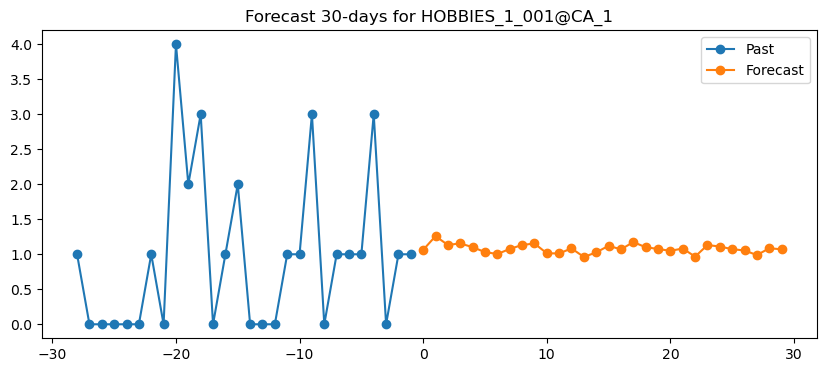

In [6]:
# ---------------- multi_horizon_forecast.py ----------------
import os
import time
import random
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---------------- Settings ----------------
CSV_PATH = r"C:\Users\Lenovo\Documents\m5_preprocessed_small.csv"  # update path
INPUT_WINDOW = 28
HORIZON = 30
BATCH_SIZE = 64
EPOCHS = 20
LR = 1e-3
TRAIN_VAL_SPLIT = 0.8
SEED = 42
MODEL_TYPE = "lstm_mlp"   # "lstm_mlp" or "nbeats"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------- Reproducibility ----------------
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ---------------- Load data ----------------
df = pd.read_csv(CSV_PATH)
df['date'] = pd.to_datetime(df['date'])
print("Loaded data shape:", df.shape)

FEATURE_COLS = ['sales','sell_price','dayofweek','month','event_1_flag','event_2_flag']
TARGET_COL = 'sales'

# ---------------- Create sequences ----------------
def create_sequences(df, input_len=INPUT_WINDOW, horizon=HORIZON):
    rows = []
    grouped = df.sort_values('date').groupby(['item_id','store_id'])
    for (item, store), g in grouped:
        g = g.reset_index(drop=True)
        values = g[FEATURE_COLS].values
        sales = g[TARGET_COL].values
        n = len(g)
        if n < input_len + horizon:
            continue
        for i in range(n - input_len - horizon + 1):
            X = values[i:i+input_len].astype(np.float32)
            y = sales[i+input_len:i+input_len+horizon].astype(np.float32)
            start_date = g.loc[i+input_len-1, 'date']
            rows.append({'item_id': item, 'store_id': store, 'start_date': start_date, 'X': X, 'y': y})
    return pd.DataFrame(rows)

print("Creating sequences...")
seq_df = create_sequences(df)
print("Total sequences:", len(seq_df))

# ---------------- Train/Val split ----------------
seq_df = seq_df.sort_values('start_date').reset_index(drop=True)
n_train = int(len(seq_df) * TRAIN_VAL_SPLIT)
train_df = seq_df.iloc[:n_train].reset_index(drop=True)
val_df = seq_df.iloc[n_train:].reset_index(drop=True)
print(f"Train: {len(train_df)}, Val: {len(val_df)}")

# ---------------- Dataset ----------------
class MultiHorizonDataset(Dataset):
    def __init__(self, df):
        self.df = df
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        return torch.tensor(row['X']), torch.tensor(row['y'])

train_loader = DataLoader(MultiHorizonDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(MultiHorizonDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)

# ---------------- Models ----------------
class LSTM_MLP(nn.Module):
    def __init__(self, n_features, hidden_dim=128, num_layers=2, horizon=HORIZON):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, horizon)
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.mlp(last)

n_features = len(FEATURE_COLS)
if MODEL_TYPE == "lstm_mlp":
    model = LSTM_MLP(n_features).to(DEVICE)
else:
    raise ValueError("Unknown MODEL_TYPE")

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ---------------- Training ----------------
def eval_model(loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            out = model(Xb)
            preds.append(out.cpu().numpy())
            trues.append(yb.cpu().numpy())
    return np.vstack(preds), np.vstack(trues)

best_val = float('inf')
print("Training...")
for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0
    count = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        out = model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * Xb.size(0)
        count += Xb.size(0)
    train_loss = total_loss / count

    preds_val, trues_val = eval_model(val_loader)
    val_loss = mean_squared_error(trues_val.flatten(), preds_val.flatten())

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "best_model.pth")

    print(f"Epoch {epoch}/{EPOCHS} — train_mse: {train_loss:.6f}, val_mse: {val_loss:.6f}")

print("Training finished. Best val_mse:", best_val)

# ---------------- KPI Calculation ----------------
model.load_state_dict(torch.load("best_model.pth", map_location=DEVICE))
model.to(DEVICE)
preds_val, trues_val = eval_model(val_loader)

# Expand item/store IDs to match flattened horizon predictions
item_ids_exp = np.repeat(val_df['item_id'].values, HORIZON)
store_ids_exp = np.repeat(val_df['store_id'].values, HORIZON)

df_pred = pd.DataFrame({
    'item_id': item_ids_exp,
    'store_id': store_ids_exp,
    'actual': trues_val.flatten(),
    'forecast': preds_val.flatten()
})

def mape(y_true, y_pred): return np.mean(np.abs((y_true - y_pred)/np.maximum(y_true,1)))*100
def bias(y_true, y_pred): return np.mean(y_pred - y_true)
def stockout_rate(y_true, y_pred, threshold=0.5): return np.mean((y_pred<=threshold) & (y_true>0))

kpi = df_pred.groupby(['item_id','store_id']).apply(
    lambda g: pd.Series({
        'MAPE': mape(g['actual'], g['forecast']),
        'Bias': bias(g['actual'], g['forecast']),
        'Stockout_rate': stockout_rate(g['actual'], g['forecast'])
    })
).reset_index()

print("\nKPI per SKU/store:")
print(kpi)

# ---------------- Example Forecast ----------------
example_item = df['item_id'].unique()[0]
example_store = df['store_id'].unique()[0]
group = df[(df['item_id']==example_item) & (df['store_id']==example_store)].sort_values('date')
if len(group) >= INPUT_WINDOW:
    last_window = group[FEATURE_COLS].values[-INPUT_WINDOW:].astype(np.float32)
    X_input = torch.tensor(last_window).unsqueeze(0).to(DEVICE)
    model.eval()
    with torch.no_grad():
        forecast = model(X_input).cpu().numpy().ravel()
    plt.figure(figsize=(10,4))
    plt.plot(range(-INPUT_WINDOW,0), group[TARGET_COL].values[-INPUT_WINDOW:], marker='o', label='Past')
    plt.plot(range(0,HORIZON), forecast, marker='o', label='Forecast')
    plt.legend(); plt.title(f"Forecast {HORIZON}-days for {example_item}@{example_store}")
    plt.show()


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21208\784574512.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kpi_df = df.groupby(['item_id', 'store_id']).apply(



KPI per SKU/store:
  item_id store_id        MAPE   Bias  Stockout_rate  Overstock_rate
0  item_0  store_0   72.669626 -30.00            0.0        0.000000
1  item_0  store_1  245.158637  19.25            0.0        0.500000
2  item_0  store_2   69.411765 -59.00            0.0        0.000000
3  item_1  store_0   28.578902 -14.00            0.0        0.333333
4  item_1  store_1  140.757576  27.00            0.0        1.000000

Top 5 SKUs by MAPE:
    item_id store_id         MAPE       Bias  Stockout_rate  Overstock_rate
16  item_6  store_0  1115.114104  27.333333            0.0        0.666667
17  item_6  store_1   737.487437  -6.500000            0.0        0.500000
15  item_5  store_2   548.705613  18.666667            0.0        0.666667
21  item_7  store_2   460.580990   5.200000            0.0        0.400000
25  item_9  store_0   387.427043 -21.142857            0.0        0.285714

Top 5 SKUs by Overstock Rate:
    item_id store_id         MAPE       Bias  Stockout_rate  Ov

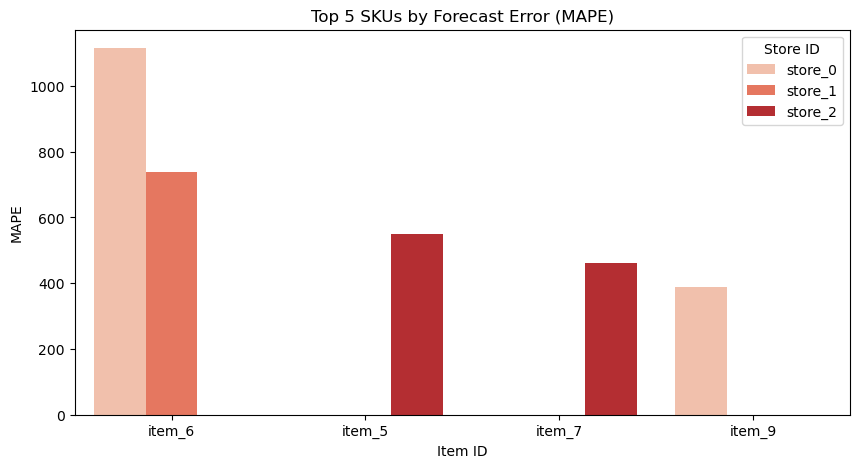

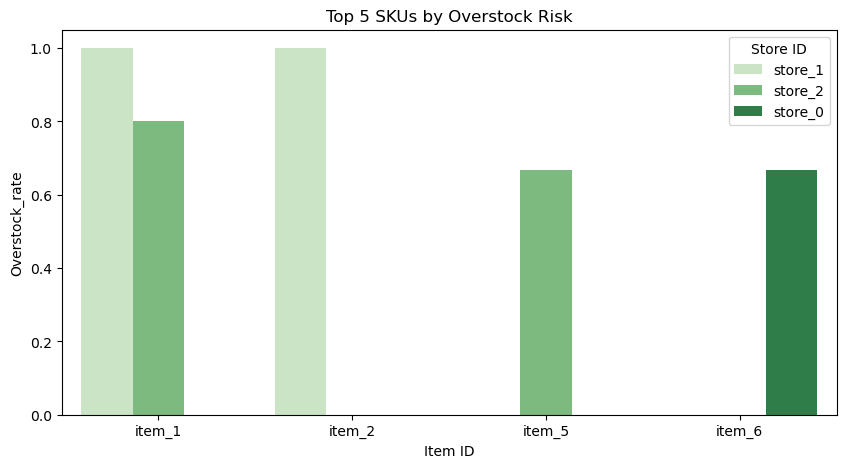


Top 5 SKUs by Stockout Rate:
          item_id store_id       MAPE      Bias  Stockout_rate
20  HOBBIES_1_007     CA_3  47.369963  0.157617       0.254301
19  HOBBIES_1_007     CA_2  48.351258  0.200461       0.189617
18  HOBBIES_1_007     CA_1  51.876253  0.138846       0.178142
3   HOBBIES_1_002     CA_1  49.261209  0.265425       0.160215
5   HOBBIES_1_002     CA_3  46.353114  0.372436       0.052151


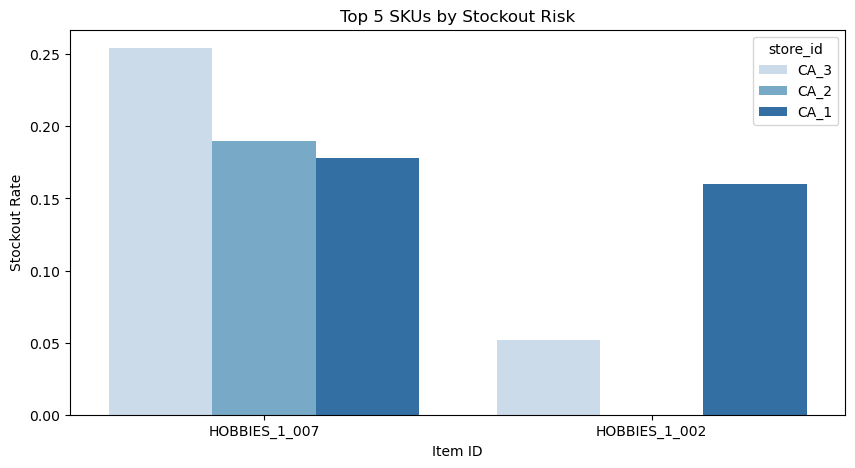

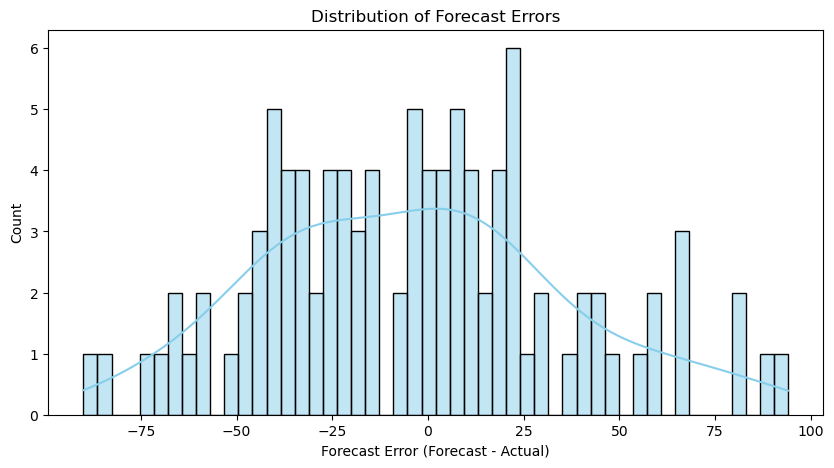


Inventory Metrics (Safety Stock & Reorder Point):
   item_id store_id  mean_demand  std_residual  safety_stock  reorder_point
0  item_0  store_0    51.000000     16.970563     74.084816     431.084816
1  item_0  store_1    32.750000     48.286472    210.794092     440.044092
2  item_0  store_2    85.000000           NaN           NaN            NaN
3  item_1  store_0    56.333333     24.576411    107.288070     501.621403
4  item_1  store_1    18.500000     14.142136     61.737347     191.237347

Full Metrics Table:
  item_id store_id        MAPE   Bias  Stockout_rate  Overstock_rate  \
0  item_0  store_0   72.669626 -30.00            0.0        0.000000   
1  item_0  store_1  245.158637  19.25            0.0        0.500000   
2  item_0  store_2   69.411765 -59.00            0.0        0.000000   
3  item_1  store_0   28.578902 -14.00            0.0        0.333333   
4  item_1  store_1  140.757576  27.00            0.0        1.000000   

   mean_demand  std_residual  safety_stock  

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_21208\784574512.py:70: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  inventory_metrics = df_pred.groupby(['item_id','store_id']).apply(


In [8]:
# ---------------- multi_horizon_analysis_fixed.py ----------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------ UTILITY FUNCTIONS ------------------
def safe_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def bias(y_true, y_pred):
    return np.mean(y_pred - y_true)

def stockout_rate(y_true, y_pred, threshold=0):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0
    if mask.sum() == 0:
        return 0
    return np.mean(y_pred[mask] <= threshold)

def overstock_rate(y_true, y_pred, threshold=0):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0
    if mask.sum() == 0:
        return 0
    return np.mean(y_pred[mask] > y_true[mask] + threshold)

# ------------------ KPI CALCULATION ------------------
def calculate_kpis(df):
    kpi_df = df.groupby(['item_id', 'store_id']).apply(
        lambda g: pd.Series({
            'MAPE': safe_mape(g['actual'], g['forecast']),
            'Bias': bias(g['actual'], g['forecast']),
            'Stockout_rate': stockout_rate(g['actual'], g['forecast']),
            'Overstock_rate': overstock_rate(g['actual'], g['forecast'])
        })
    ).reset_index()
    return kpi_df

# ------------------ TOP 5 ANALYSIS ------------------
def top_n_kpis(kpi_df, metric, n=5, ascending=False):
    return kpi_df.sort_values(metric, ascending=ascending).head(n)

# ------------------ PLOTTING FUNCTIONS ------------------
def plot_top5_bar(top5_df, metric, title, palette='viridis'):
    plt.figure(figsize=(10,5))
    sns.barplot(x='item_id', y=metric, hue='store_id', data=top5_df, palette=palette, dodge=True)
    plt.title(title)
    plt.xlabel('Item ID')
    plt.ylabel(metric)
    plt.legend(title='Store ID')
    plt.show()

def plot_error_histogram(df_pred):
    df_pred['error'] = df_pred['forecast'] - df_pred['actual']
    plt.figure(figsize=(10,5))
    sns.histplot(df_pred['error'], bins=50, kde=True, color='skyblue')
    plt.title('Distribution of Forecast Errors')
    plt.xlabel('Forecast Error (Forecast - Actual)')
    plt.ylabel('Count')
    plt.show()

# ------------------ INVENTORY METRICS ------------------
def calculate_inventory_metrics(df_pred, lead_time=7, z=1.65):
    df_pred['residual'] = df_pred['actual'] - df_pred['forecast']
    inventory_metrics = df_pred.groupby(['item_id','store_id']).apply(
        lambda g: pd.Series({
            'mean_demand': g['actual'].mean(),
            'std_residual': g['residual'].std(),
            'safety_stock': z * g['residual'].std() * np.sqrt(lead_time),
            'reorder_point': g['actual'].mean() * lead_time + z * g['residual'].std() * np.sqrt(lead_time)
        })
    ).reset_index()
    return inventory_metrics

# ------------------ MAIN WORKFLOW ------------------
def run_analysis(df_predictions):
    # KPI calculation
    kpi_per_sku = calculate_kpis(df_predictions)
    print("\nKPI per SKU/store:")
    print(kpi_per_sku.head())

    # Top 5 analysis (MAPE + Overstock only)
    top5_mape = top_n_kpis(kpi_per_sku, 'MAPE', n=5, ascending=False)
    top5_overstock = top_n_kpis(kpi_per_sku, 'Overstock_rate', n=5, ascending=False)

    print("\nTop 5 SKUs by MAPE:\n", top5_mape)
    print("\nTop 5 SKUs by Overstock Rate:\n", top5_overstock)

    # Plotting
    plot_top5_bar(top5_mape, 'MAPE', 'Top 5 SKUs by Forecast Error (MAPE)', palette='Reds')
    plot_top5_bar(top5_overstock, 'Overstock_rate', 'Top 5 SKUs by Overstock Risk', palette='Greens')
    # ---------------- Top 5 SKUs by Stockout Rate ----------------
    top_stockout = kpi.sort_values('Stockout_rate', ascending=False).head(5)
    print("\nTop 5 SKUs by Stockout Rate:")
    print(top_stockout)

    plt.figure(figsize=(10,5))
    sns.barplot(x='item_id', y='Stockout_rate', hue='store_id', data=top_stockout, palette='Blues')
    plt.title("Top 5 SKUs by Stockout Risk")
    plt.ylabel("Stockout Rate")
    plt.xlabel("Item ID")
    plt.show()

    
    # Forecast error histogram
    plot_error_histogram(df_predictions)

    # Inventory metrics
    inventory_metrics = calculate_inventory_metrics(df_predictions)
    print("\nInventory Metrics (Safety Stock & Reorder Point):\n", inventory_metrics.head())

    # Merge KPIs + inventory metrics
    full_metrics = pd.merge(kpi_per_sku, inventory_metrics, on=['item_id','store_id'])
    return full_metrics

# ------------------ EXECUTE SCRIPT ------------------
if __name__ == "__main__":
    # Dummy example for testing
    num_items = 10
    num_stores = 3
    np.random.seed(42)
    df_predictions = pd.DataFrame({
        'item_id': np.random.choice([f'item_{i}' for i in range(num_items)], size=100),
        'store_id': np.random.choice([f'store_{i}' for i in range(num_stores)], size=100),
        'actual': np.random.randint(0, 100, size=100),
        'forecast': np.random.randint(0, 100, size=100)
    })
    
    full_metrics = run_analysis(df_predictions)
    print("\nFull Metrics Table:")
    print(full_metrics.head())



In [12]:
# Advanced AI Recommendation Engine
import numpy as np
import pandas as pd

def detect_demand_spike(item_id, store_id, df_pred, lookback_days=14, baseline_days=60, date_col='date'):
    """
    Detect a recent demand spike using df_pred (must contain date, item_id, store_id, actual).
    Returns (spike_ratio, spike_flag) where spike_ratio = recent_mean / baseline_mean (or np.nan).
    """
    if df_pred is None or date_col not in df_pred.columns:
        return np.nan, False

    # Ensure date is datetime
    dfp = df_pred.copy()
    dfp[date_col] = pd.to_datetime(dfp[date_col], errors='coerce')
    dfp = dfp.dropna(subset=[date_col])

    mask = (dfp['item_id'] == item_id) & (dfp['store_id'] == store_id)
    sub = dfp.loc[mask].sort_values(date_col)
    if sub.empty:
        return np.nan, False

    latest_date = sub[date_col].max()
    recent_start = latest_date - pd.Timedelta(days=lookback_days)
    baseline_start = latest_date - pd.Timedelta(days=baseline_days + lookback_days)

    recent = sub[(sub[date_col] > recent_start)]
    baseline = sub[(sub[date_col] > baseline_start) & (sub[date_col] <= recent_start)]

    recent_mean = recent['actual'].mean() if not recent.empty else np.nan
    baseline_mean = baseline['actual'].mean() if not baseline.empty else np.nan

    if pd.isna(recent_mean) or pd.isna(baseline_mean) or baseline_mean == 0:
        return np.nan, False

    ratio = recent_mean / baseline_mean
    spike_flag = ratio >= 1.5  # e.g., 50%+ increase
    return float(ratio), bool(spike_flag)

def advanced_recommendation_for_row(row, df_pred=None, params=None):
    """
    Generate detailed recommendation for a single row (series from full_metrics).
    params: dict for thresholds and defaults.
    """
    if params is None:
        params = {}
    # thresholds / defaults
    stockout_thresh = params.get('stockout_thresh', 0.25)
    overstock_thresh = params.get('overstock_thresh', 0.30)
    mape_high = params.get('mape_high', 100.0)          # percent
    variability_ratio_thresh = params.get('var_ratio', 0.5)  # std_residual / mean_demand
    min_mean_demand = params.get('min_mean_demand', 1.0)    # below this considered slow-moving
    lead_time = params.get('lead_time', 7)

    recs = []
    severity_score = 0  # higher = more severe
    suggested_safety = np.nan
    suggested_rop = np.nan

    # safe-get helpers
    def safe(x):
        return row[x] if x in row.index else np.nan

    MAPE = safe('MAPE')
    Stockout = safe('Stockout_rate')
    Overstock = safe('Overstock_rate')
    mean_d = safe('mean_demand')
    std_res = safe('std_residual')
    safety_stock = safe('safety_stock')
    rop = safe('reorder_point')

    # 1) Stockout risk -> increase safety stock
    if not pd.isna(Stockout) and Stockout > stockout_thresh:
        increase_pct = min(0.25 + (Stockout - stockout_thresh), 0.6)  # escalate
        suggested_safety = np.nan if pd.isna(safety_stock) else float(safety_stock * (1 + increase_pct))
        recs.append(f"High stockout risk ({Stockout:.2f}). Increase safety stock by ~{int(increase_pct*100)}% to about {np.nan_to_num(suggested_safety):.0f}.")
        severity_score += 3

    # 2) Overstock risk -> reduce order size or ROP
    if not pd.isna(Overstock) and Overstock > overstock_thresh:
        reduce_pct = min(0.15 + (Overstock - overstock_thresh)*0.5, 0.5)
        suggested_rop = np.nan if pd.isna(rop) else max(0, float(rop * (1 - reduce_pct)))
        recs.append(f"High overstock risk ({Overstock:.2f}). Reduce reorder point/orders by ~{int(reduce_pct*100)}% to about {np.nan_to_num(suggested_rop):.0f}.")
        severity_score += 2

    # 3) High MAPE -> model action
    if not pd.isna(MAPE) and MAPE > mape_high:
        recs.append(f"Very high MAPE ({MAPE:.2f}%). Retrain model, add features (promotions/holiday), or use SKU-specific model.")
        severity_score += 3

    # 4) Variability -> dynamic safety stock
    if not pd.isna(std_res) and not pd.isna(mean_d) and mean_d > 0:
        var_ratio = std_res / mean_d
        if var_ratio > variability_ratio_thresh:
            # suggest increasing safety proportionally
            inc_pct = min(var_ratio * 0.5, 0.6)
            suggested_safety = np.nan if pd.isna(safety_stock) else float(safety_stock * (1 + inc_pct))
            recs.append(f"High demand variability (std/mean={var_ratio:.2f}). Consider dynamic safety stock (+{int(inc_pct*100)}%).")
            severity_score += 2

    # 5) Slow-moving detection (low mean demand but high overstock)
    if (not pd.isna(mean_d) and mean_d <= min_mean_demand) or (not pd.isna(mean_d) and mean_d < 2 and not pd.isna(Overstock) and Overstock > 0.4):
        recs.append("Low mean demand detected — SKU may be slow-moving. Consider markdown, slow-moving SKU policy, or reduce replenishment frequency.")
        severity_score += 1

    # 6) Reorder point check against lead time
    if not pd.isna(mean_d):
        expected_during_lead = mean_d * lead_time
        if not pd.isna(rop) and rop < expected_during_lead:
            # need to increase ROP
            suggested_rop = float(max(suggested_rop if not pd.isna(suggested_rop) else rop, expected_during_lead + (0 if pd.isna(std_res) else 1.65*std_res*np.sqrt(lead_time))))
            recs.append(f"ROP ({rop:.1f}) < expected demand during lead time ({expected_during_lead:.1f}). Increase ROP to at least {suggested_rop:.0f}.")
            severity_score += 2

    # 7) Demand spike detection using df_pred (optional; requires date column)
    spike_ratio, spike_flag = detect_demand_spike(row.get('item_id'), row.get('store_id'), df_pred) if df_pred is not None else (np.nan, False)
    if spike_flag:
        recs.append(f"Recent demand spike detected (recent/baseline ≈ {spike_ratio:.2f}). Consider temporary safety stock increase and investigate driver (promo/seasonality).")
        severity_score += 3

    # 8) Inventory aging / overstock aging heuristic
    if not pd.isna(Overstock) and not pd.isna(mean_d) and mean_d < 5 and Overstock > 0.5:
        recs.append("High overstock combined with low demand — consider clearance or transfer to other stores.")
        severity_score += 2

    # Final fallback
    if len(recs) == 0:
        recs.append("Performance within acceptable bounds. Monitor regularly.")

    # Map severity_score to label
    if severity_score >= 6:
        severity = "Critical"
    elif severity_score >= 4:
        severity = "High"
    elif severity_score >= 2:
        severity = "Medium"
    else:
        severity = "Low"

    # Build recommendation text
    recommendation_text = " | ".join(recs)
    return {
        "AI_Recommendation": recommendation_text,
        "Recommendation_Severity": severity,
        "Suggested_Safety_Stock": suggested_safety,
        "Suggested_Reorder_Point": suggested_rop,
        "Demand_Spike_Ratio": spike_ratio
    }

# Apply engine across full_metrics (safe)
def apply_advanced_recs(full_metrics, df_pred=None, params=None):
    results = full_metrics.apply(lambda r: pd.Series(advanced_recommendation_for_row(r, df_pred=df_pred, params=params)), axis=1)
    # join back
    out = pd.concat([full_metrics.reset_index(drop=True), results.reset_index(drop=True)], axis=1)
    return out

